# ANALISI CONVERGENZA NEURAL NETWORK

### importazioni

In [1]:
from ML_app.neural_network import neural_network
from ML_app.cost_functions import sigmoide

In [2]:
import pickle as pkl
import numpy as np

with open('../data/ottani_NIR.pkl', 'rb') as f:
    dizionario = pkl.load(f)
    
# dati train
train_ones = dizionario['train']['NIR']['ones']
train_zeros = dizionario['train']['NIR']['zeros']
train_labels = dizionario['train']['labels']
train_x = np.concatenate((train_zeros, train_ones))

# dati test
test_ones = dizionario['test']['NIR']['ones']
test_zeros = dizionario['test']['NIR']['zeros']
test_labels = dizionario['test']['labels']
test_x = np.concatenate((test_zeros, test_ones))

### SMOOTHING 

In [3]:
from scipy.signal import savgol_filter

window_size = 11
poly_order = 3

for i in range(train_x.shape[0]):
    train_x[i] = savgol_filter(train_x[i], window_size, poly_order)

for j in range(test_x.shape[0]):
    test_x[j] = savgol_filter(test_x[j], window_size, poly_order)

---

## neural network con PCA

In [4]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [5]:
n_epoche = 200_000

# normalizzazione
scaler = MinMaxScaler()
train_x = scaler.fit_transform(train_x)
test_x = scaler.transform(test_x)
# pca
pca = PCA(n_components=7)
train_x = pca.fit_transform(train_x)
test_x = pca.transform(test_x)
# estimator
nn_est = neural_network(
    epoche = n_epoche,
    nn_learning_rate = 0.5,
    activation_function = 'sigmoide',
    return_errors = True,
    convergence_tol = 1e-03
)


In [6]:
nn_est.fit(train_x, train_labels)
print(f'converged: {nn_est._has_converged} | if yes in: {nn_est._convergence_idx}')
lista_somma_errori = nn_est.errors_

converged: True | if yes in: 92307


In [7]:
nn_est.errors_.shape

(92307,)

### training

In [8]:
import matplotlib.pyplot as plt

#fig, ax = plt.subplots(1, 2, figsize=(20, 8), dpi=150)
'''
x = range(np.array(lista_ultimi_errori).shape[0])#[:1000]
y = np.array(lista_ultimi_errori)#[:1000]

plt.figure(figsize=(8,4), dpi=200)
plt.scatter(x,y)
plt.xlabel("Epoca")
plt.ylabel("MSE al termine epoca")'''

'\nx = range(np.array(lista_ultimi_errori).shape[0])#[:1000]\ny = np.array(lista_ultimi_errori)#[:1000]\n\nplt.figure(figsize=(8,4), dpi=200)\nplt.scatter(x,y)\nplt.xlabel("Epoca")\nplt.ylabel("MSE al termine epoca")'

Text(0, 0.5, 'Somma errori')

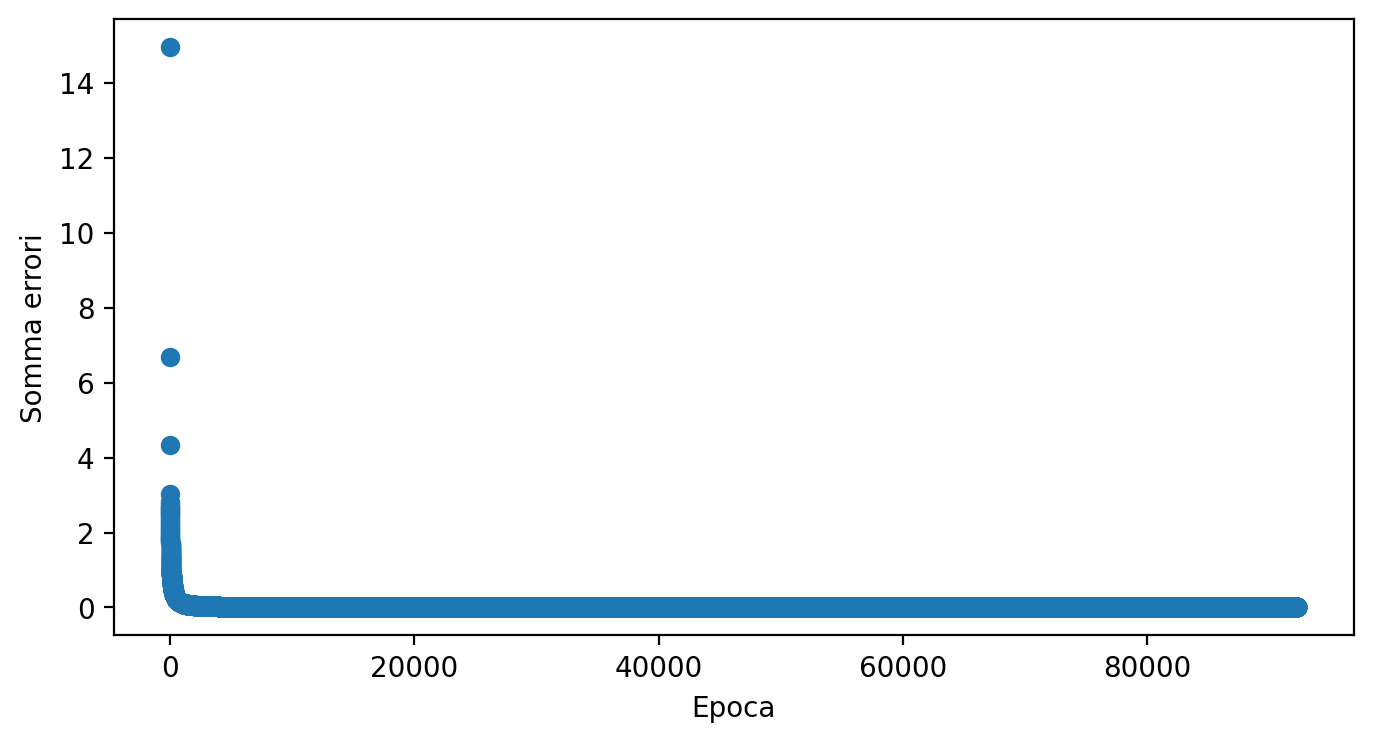

In [ ]:
x = range(nn_est._convergence_idx) #[:1000]
y = np.array(lista_somma_errori)#[:1000]

plt.figure(figsize=(8,4), dpi=200)
plt.scatter(x,y)
plt.xlabel("Epoca")
plt.ylabel("Somma errori")
plt.yscale('log')

### test

In [10]:
prediction = nn_est.predict(test_x)
prediction

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0])

studio convergenza

In [11]:
from subroutines import evaluate_lr_tol_convergence
from concurrent.futures import ProcessPoolExecutor

# parametri analisi
list_learning_rate = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
n_iter = len(list_learning_rate)
max_epoche = [10_000_000]*n_iter
list_tolerance = [1e-04, 5e-04, 1e-03, 5e-03, 1e-02, 1e-01]

results = {}

for tol in list_tolerance:
    print(f'tol: {tol}')
    # Multiprocessing
    if __name__ == '__main__':
        print(f"Avvio analisi su {len(list_learning_rate)} learning rates in parallelo...")
        
        with ProcessPoolExecutor() as executor:
            # Passiamo i parametri usando una list comprehension o map
            # executor.map mantiene l'ordine della lista originale
            results[tol] = list(executor.map(
                evaluate_lr_tol_convergence, 
                max_epoche,
                list_learning_rate, 
                [tol]*n_iter,
                [train_x]*n_iter, 
                [train_labels]*n_iter,
            ))

print("Analisi completata.")


tol: 0.0001
Avvio analisi su 8 learning rates in parallelo...


tol: 0.0005
Avvio analisi su 8 learning rates in parallelo...
tol: 0.001
Avvio analisi su 8 learning rates in parallelo...
tol: 0.005
Avvio analisi su 8 learning rates in parallelo...
tol: 0.01
Avvio analisi su 8 learning rates in parallelo...
tol: 0.1
Avvio analisi su 8 learning rates in parallelo...
Analisi completata.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
import seaborn as sns

# Trasformiamo i risultati in una matrice (Tolleranze sulle righe, LR sulle colonne)
data_matrix = []
for tol in list_tolerance:
    data_matrix.append(results[tol])

data_matrix = np.array(data_matrix)

plt.figure(figsize=(12, 8))

# Usiamo LogNorm per gestire la differenza di ordini di grandezza tra le epoche
# Scegliamo una colormap che va dal chiaro (veloce) allo scuro (lento/non convergente)
pcm = plt.pcolormesh(
    list_learning_rate, 
    list_tolerance, 
    data_matrix, 
    norm=colors.LogNorm(vmin=data_matrix.min(), vmax=data_matrix.max()),
    shading='auto',
    cmap='viridis_r' # _r inverte il colore: giallo = veloce, viola = lento
)

# Essendo i parametri su scale logaritmiche, impostiamo gli assi di conseguenza
plt.xscale('log')
plt.yscale('log')

plt.colorbar(pcm, label='Epoche fino a convergenza (scala log)')
plt.xlabel('Learning Rate')
plt.ylabel('Tolleranza (Convergence Tol)')
plt.title('Mappa di Convergenza: LR vs Tolleranza')

# Opzionale: aggiungiamo i valori numerici sopra i quadratini
for i, tol in enumerate(list_tolerance):
    for j, lr in enumerate(list_learning_rate):
        val = data_matrix[i, j]
        # Se ha raggiunto il massimo delle epoche, scriviamo "NC" (Non Converged)
        label = f"{val:.0e}" if val < 10_000_000 else "N.C."
        plt.text(lr, tol, label, ha='center', va='center', color='white', fontsize=8, alpha=0.7)

plt.show()

NameError: name 'list_tolerance' is not defined

---

studio vecchio

In [13]:
from subroutines import convergence_idx

i = convergence_idx(
    lista_somma_errori,
    tol = 1e-03,
    debug = True
)
i

Termina per endstep


92307

In [14]:
from subroutines import evaluate_convergence_lr
from concurrent.futures import ProcessPoolExecutor

list_learning_rate = [0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 0.9]
n_iter = len(list_learning_rate)
n_epoche = [10_000_000]*n_iter
n_epoche[0], n_epoche[1] = 100_000_000, 50_000_000

list_convergence_idx = []

# Multiprocessing
if __name__ == '__main__':
    print(f"Avvio analisi su {len(list_learning_rate)} learning rates in parallelo...")
    
    with ProcessPoolExecutor() as executor:
        # Passiamo i parametri usando una list comprehension o map
        # executor.map mantiene l'ordine della lista originale
        results = list(executor.map(
            evaluate_convergence_lr, 
            list_learning_rate, 
            n_epoche,
            [train_x]*n_iter, 
            [train_labels]*n_iter,
        ))

    list_convergence_idx = results
    print("Analisi completata.")

Avvio analisi su 7 learning rates in parallelo...


: 

: 

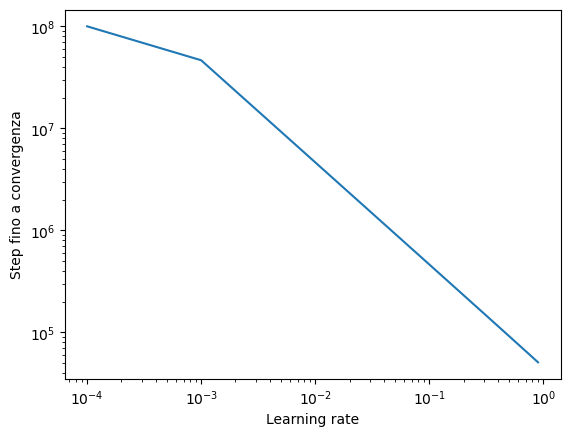

In [ ]:
x = list_learning_rate
y = list_convergence_idx
y[0] = 1e8

plt.plot(x,y)
plt.xlabel('Learning rate')
plt.xscale('log')
plt.ylabel('Step fino a convergenza')
plt.yscale('log')
plt.show()